# 1.1 Esperimentu Osoa
Notebook honek sistema osoa integratzen du: **Sortu -> Itzala -> Banatu -> Entrenatu -> Ebaluatu**.

Helburua:
1. Datu linealak sortu.
2. Erdian zirkulu formako "Informazio Itzala" jarri.
3. Erregresio Lineala entrenatu (itzala ikusi gabe).
4. Ikusi nola iragartzen dituen puntuak itzalaren barruan.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Proiektuaren erroa gehitu
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Modulu guztiak inportatu
from src.generators import Math2DGenerator
from src.noise import AbsoluteGaussianNoise, AdaptiveGaussianNoise
from src.shadows import BandShadow
from src.splitter import GapSplitter
from src.models import LinearRegressionModel
from src.orchestrator import ExperimentOrchestrator
from src.visualization import plot_experiment_results

### 1. Esperimentuaren Konfigurazioa

In [2]:
# A) Generadorea (y = 2x + 5)
linear_func = lambda x: 2.0 * x + 5.0
generator = Math2DGenerator(linear_func, seed=42)

# B) Zarata Estrategia
noise = AbsoluteGaussianNoise(std_dev=2.0, seed=42)

# C) Itzala (Hutsunea erdian)
shadow = BandShadow(axis= 'x', min_val=5, max_val=12)

# D) Banatzailea eta Modeloa
splitter = GapSplitter(test_size=0.2, random_state=42)
model = LinearRegressionModel()

# E) Orkestradorea prestatu
orchestrator = ExperimentOrchestrator(generator, splitter, model)

### 2. Esperimentua Exekutatu (Run)

In [3]:
results = orchestrator.run(
    n_samples=300,
    x_range=(0, 20),
    noise_strategy=noise,
    shadow=shadow
)

# Emaitzak bistaratu
metrics = results.metrics
print("--- Emaitzak (MSE Errorea) ---")
print(f"Train Error:      {metrics.mse_train:.4f}")
print(f"Visible Test:     {metrics.mse_test_visible:.4f}")
print(f"SHADOW Test:      {metrics.mse_test_shadow:.4f} (Hau da garrantzitsuena)")

--- Emaitzak (MSE Errorea) ---
Train Error:      3.4138
Visible Test:     3.3344
SHADOW Test:      3.5251 (Hau da garrantzitsuena)


### 3. Bistaraketa Finala

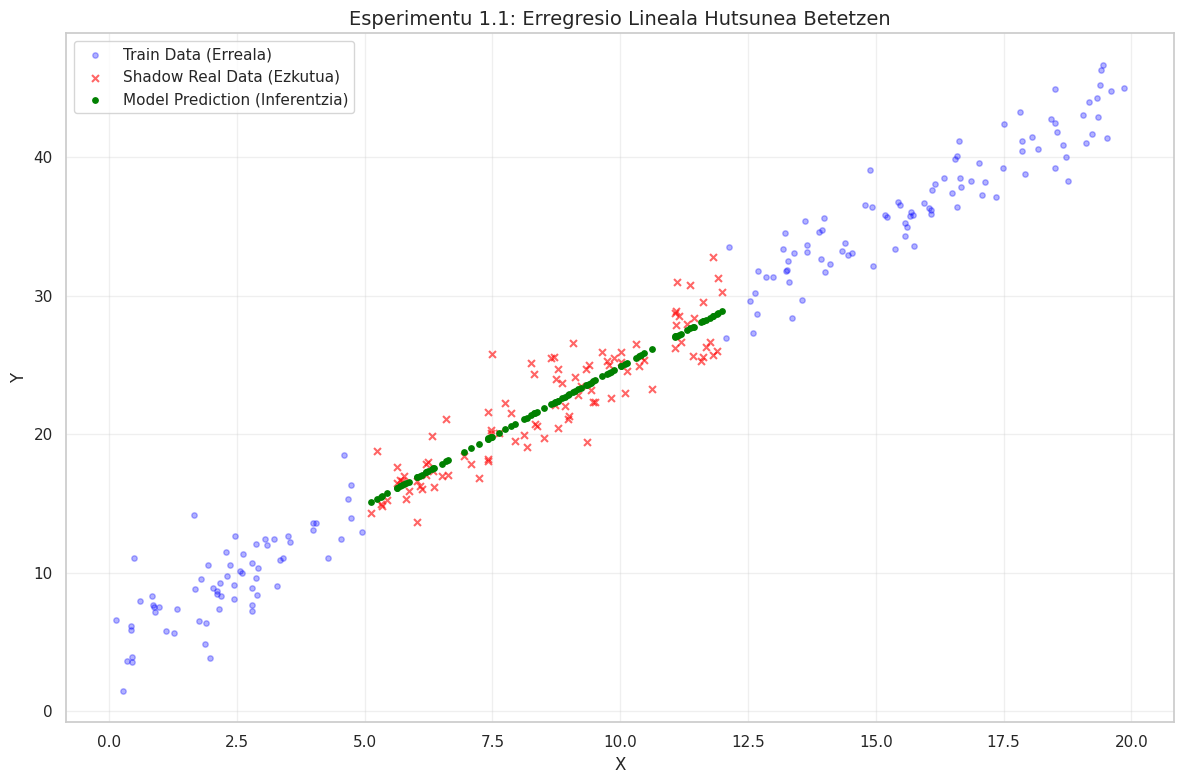

In [4]:
plot_experiment_results(
    results.split_data,
    results.predictions,
    title="Esperimentu 1.1: Erregresio Lineala Hutsunea Betetzen"
)